In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from pathlib import Path

## Load Raw Data

In [2]:
RAW = Path("../data/raw") 
orders = pd.read_csv(RAW / "olist_orders_dataset.csv") 
customers = pd.read_csv(RAW / "olist_customers_dataset.csv") 
items = pd.read_csv(RAW / "olist_order_items_dataset.csv") 
payments = pd.read_csv(RAW / "olist_order_payments_dataset.csv") 
reviews = pd.read_csv(RAW / "olist_order_reviews_dataset.csv") 
products = pd.read_csv(RAW / "olist_products_dataset.csv") 
sellers = pd.read_csv(RAW / "olist_sellers_dataset.csv") 
geo = pd.read_csv(RAW / "olist_geolocation_dataset.csv") 
cat_trans = pd.read_csv(RAW / "product_category_name_translation.csv") 
dfs = {"orders":orders, "customers":customers, "items":items, "payments":payments, "reviews":reviews, "products":products, "sellers":sellers, "geo":geo, "cat_trans":cat_trans}

## Parse all timestamp columns immediately

In [3]:
parse_dates = [ "order_purchase_timestamp", "order_approved_at", "order_delivered_carrier_date", "order_delivered_customer_date", "order_estimated_delivery_date" ] 
orders = pd.read_csv(RAW / "olist_orders_dataset.csv", parse_dates=parse_dates)

## Order volume over time — monthly bar chart

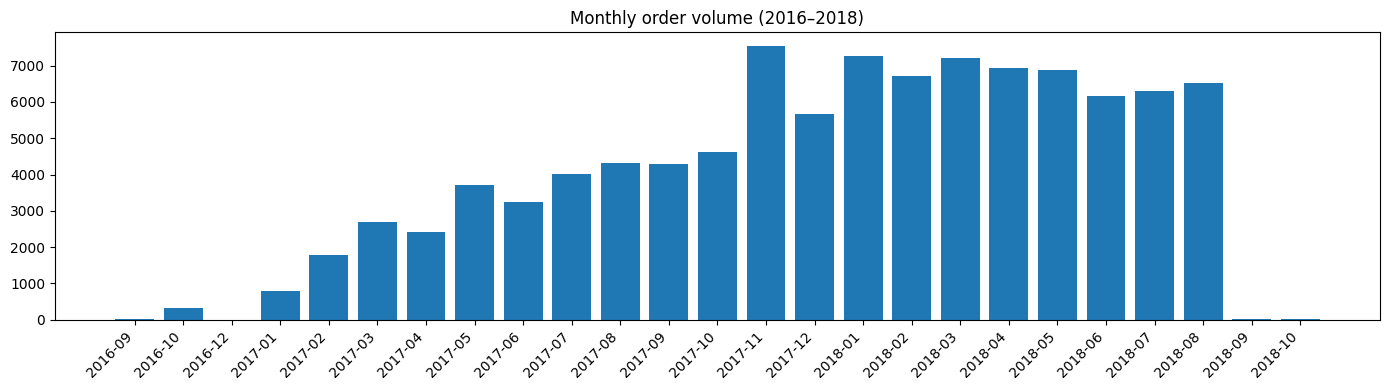

In [4]:
orders["month"] = orders["order_purchase_timestamp"].dt.to_period("M") 
monthly = orders.groupby("month").size().reset_index(name="order_count") 
fig, ax = plt.subplots(figsize=(14, 4)) 
ax.bar(monthly["month"].astype(str), monthly["order_count"]) 
ax.set_title("Monthly order volume (2016–2018)") 
plt.xticks(rotation=45, ha="right") 
plt.tight_layout() 
plt.savefig("../reports/figures/1.0-monthly-order-volume.png", dpi=150) 
plt.show()

## Order status distribution — pie or bar

In [5]:
status_counts = orders["order_status"].value_counts() 
print(status_counts) # Key question: how many are "delivered" vs "canceled" vs stuck? status_counts.plot(kind="bar", title="Order status distribution") plt.savefig("../reports/figures/1.0-order-status.png", dpi=150)


order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


## Approval time — minutes from purchase to approval

In [6]:
orders["approval_minutes"] = ( orders["order_approved_at"] - orders["order_purchase_timestamp"] ).dt.total_seconds() / 60 
print(orders["approval_minutes"].describe()) # Watch for negative values — data quality red flag neg = orders[orders["approval_minutes"] < 0] print(f"Negative approval times: {len(neg)}")

count     99281.000000
mean        625.145658
std        1562.280218
min           0.000000
25%          12.900000
50%          20.600000
75%         874.850000
max      270550.833333
Name: approval_minutes, dtype: float64


## Day-of-week & hour-of-day purchase patterns

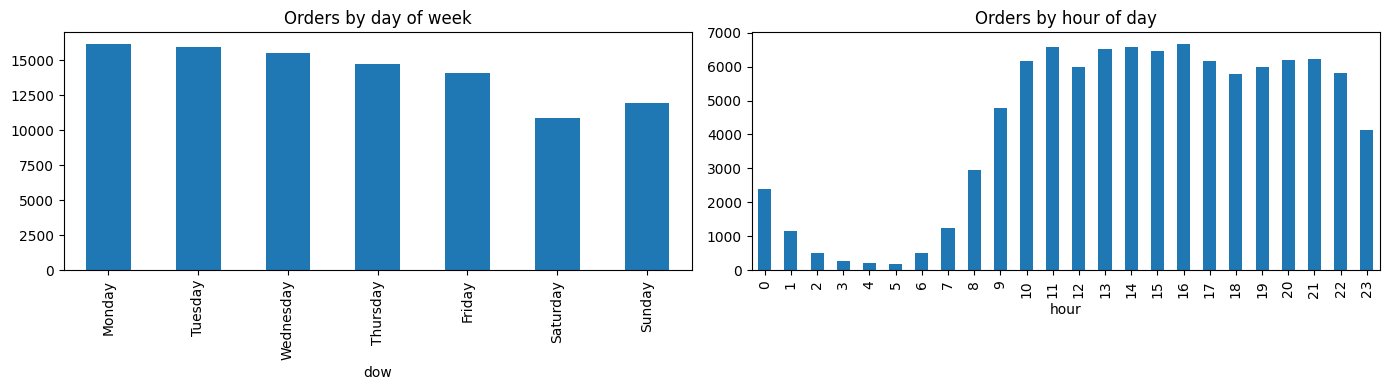

In [8]:
orders["dow"] = orders["order_purchase_timestamp"].dt.day_name() 
orders["hour"] = orders["order_purchase_timestamp"].dt.hour 
fig, axes = plt.subplots(1, 2, figsize=(14,4)) 
orders["dow"].value_counts().reindex( ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"] ).plot(kind="bar", ax=axes[0], title="Orders by day of week") 
orders["hour"].value_counts().sort_index().plot( kind="bar", ax=axes[1], title="Orders by hour of day") 
plt.tight_layout() 
plt.savefig("../reports/figures/1.0-purchase-patterns.png", dpi=150)